# Lesson 18A: Kernel Density Estimation — Theory

## Introduction

Lesson 4 fitted a Gaussian Mixture Model: assume the data came from $k$ Gaussians, estimate their parameters, and you have a density you can evaluate anywhere. That is a **parametric** answer — it works beautifully when the assumption holds and fails silently when it does not. A GMM asked to describe a uniform slab or a sharply skewed distribution will return something confident and wrong.

Kernel density estimation asks the question without the assumption. It says: I will not tell you what family this density belongs to. I will let each observed point vote for density in its own neighbourhood, add up the votes, and call the total my estimate. There is no model to be wrong about — which is the appeal, and also the catch, because everything now rests on one number: **how wide is a neighbourhood?**

That number, the bandwidth $h$, is the whole subject. Too small and the estimate is a spiky record of exactly where your sample landed; too large and every feature dissolves into one smooth hill. This lesson derives where the optimal bandwidth comes from, implements three ways of choosing it, and shows the one place KDE genuinely cannot be rescued — high dimensions, where the sample size needed for a fixed accuracy grows exponentially.

In this lesson:
1. Build KDE from the histogram, and see why bin *placement* is a defect the kernel removes
2. Compare four kernels, and demonstrate the standard claim that the kernel barely matters
3. Derive the bias–variance decomposition, the AMISE, and the $h \propto n^{-1/5}$ rule; implement Scott, Silverman and leave-one-out cross-validation
4. Watch over- and under-smoothing on a bimodal target where the truth is known
5. Measure the curse of dimensionality rather than describe it
6. Put KDE head to head with Lesson 4's GMM on two targets — one where the Gaussian family is right and one where it is wrong
7. Write a vectorised `kde()` from scratch and check it against scikit-learn and SciPy

## Table of Contents

1. [Introduction](#introduction)
2. [Required Libraries](#required-libraries)
3. [From Histograms to Kernels](#histograms)
4. [Kernels and Their Properties](#kernels)
5. [Bias, Variance and the AMISE](#amise)
6. [Choosing the Bandwidth: Scott, Silverman, Cross-Validation](#bandwidth)
7. [Over- and Under-smoothing on a Known Target](#smoothing)
8. [Multivariate KDE and the Curse of Dimensionality](#curse)
9. [Parametric versus Nonparametric: GMM against KDE](#gmm-vs-kde)
10. [From Scratch, Validated](#from-scratch)
11. [Conclusion](#conclusion)

<a name="required-libraries"></a>
## Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.neighbors import KernelDensity
from sklearn.mixture import GaussianMixture
from sklearn.datasets import load_iris
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("Libraries loaded.")

Libraries loaded.


<a name="histograms"></a>
## From Histograms to Kernels

A histogram is already a density estimate. Choose an origin $x_0$ and a bin width $h$, and

$$\hat{f}_{\text{hist}}(x) = \frac{1}{nh}\,\#\{X_i \text{ in the bin containing } x\}.$$

It has two defects, and only one of them is about bin width.

**Defect 1 — the width.** Too narrow and the estimate is noise; too wide and structure disappears. This is the bias–variance trade-off, and KDE inherits it wholesale as the bandwidth problem.

**Defect 2 — the origin.** Two histograms of the *same data* with the *same bin width* but bins shifted by half a width can tell different stories: one bimodal, one not. That is an artefact of an arbitrary choice with no basis in the data, and it is the defect KDE actually removes.

The fix is to stop asking "which bin is $x$ in?" and start asking "how many points are near $x$?" — centring a bump on every observation rather than on a fixed grid:

$$\hat{f}(x) = \frac{1}{nh}\sum_{i=1}^{n} K\!\left(\frac{x - X_i}{h}\right).$$

There is no origin left to choose. The cell below builds the same data three ways to show both defects at once.

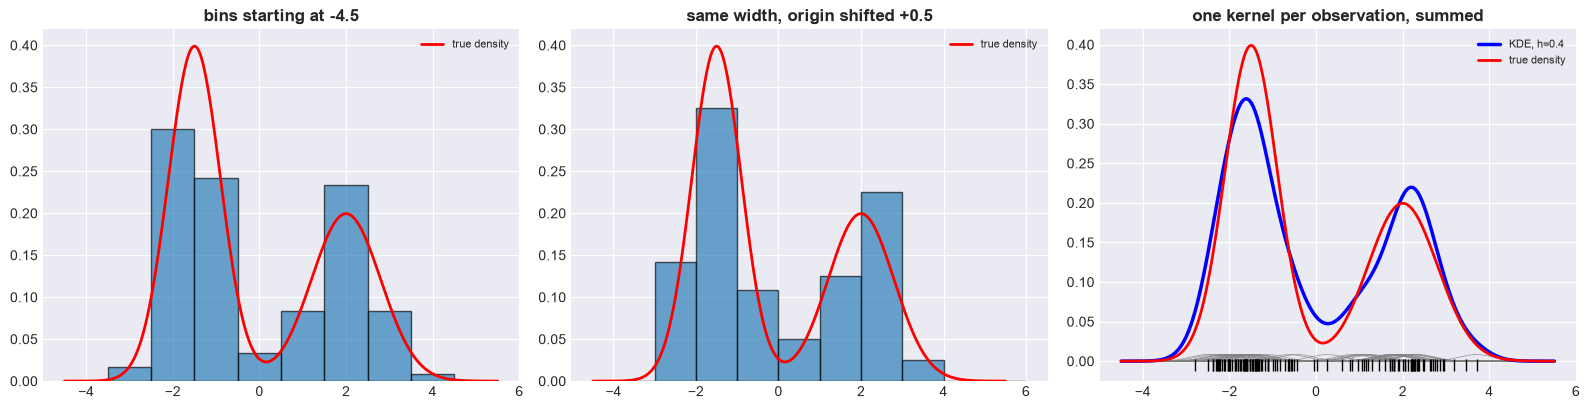

Histogram, identical bin width, origin shifted by half a bin:
  mean |difference| between the two estimates : 0.0546
  max  |difference|                           : 0.1583
  (for scale, the true density peaks at        0.3989)

The two histograms use the same data and the same width. Every bit of that difference
is an artefact of where the bins happened to start. KDE has no origin to choose.


In [2]:
# A bimodal target we will reuse all lesson: 0.6*N(-1.5, 0.6^2) + 0.4*N(2, 0.8^2)
def sample_bimodal(n, rng):
    comp = rng.random(n) < 0.6
    return np.where(comp, rng.normal(-1.5, 0.6, n), rng.normal(2.0, 0.8, n))


def true_bimodal_pdf(x):
    return 0.6 * stats.norm.pdf(x, -1.5, 0.6) + 0.4 * stats.norm.pdf(x, 2.0, 0.8)


rng = np.random.default_rng(42)
X = sample_bimodal(120, rng)
grid = np.linspace(-4.5, 5.5, 400)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# Defect 2: same width, origin shifted by half a bin
for ax, offset, ttl in [(axes[0], 0.0, 'bins starting at -4.5'),
                        (axes[1], 0.5, 'same width, origin shifted +0.5')]:
    edges = np.arange(-4.5 + offset, 5.6 + offset, 1.0)
    ax.hist(X, bins=edges, density=True, alpha=0.65, edgecolor='black')
    ax.plot(grid, true_bimodal_pdf(grid), 'r-', lw=2, label='true density')
    ax.set_title(ttl, fontweight='bold')
    ax.legend(fontsize=8)

# The kernel view: one bump per observation, summed
h = 0.4
bumps = stats.norm.pdf((grid[:, None] - X[None, :]) / h) / h
axes[2].plot(grid, bumps[:, :40] / len(X), color='grey', lw=0.6, alpha=0.7)
axes[2].plot(grid, bumps.mean(axis=1), 'b-', lw=2.5, label=f'KDE, h={h}')
axes[2].plot(grid, true_bimodal_pdf(grid), 'r-', lw=2, label='true density')
axes[2].plot(X, np.zeros_like(X) - 0.005, '|', color='black', ms=8)
axes[2].set_title('one kernel per observation, summed', fontweight='bold')
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

# Quantify defect 2 rather than leave it to the eye: how much does the estimate
# move when only the origin changes?
def hist_density(x_eval, data, width, origin):
    edges = np.arange(origin, origin + width * (int((data.max() - origin) / width) + 2), width)
    counts, e = np.histogram(data, bins=edges, density=True)
    idx = np.clip(np.searchsorted(e, x_eval, side='right') - 1, 0, len(counts) - 1)
    return counts[idx]


d0 = hist_density(grid, X, 1.0, -4.5)
d1 = hist_density(grid, X, 1.0, -4.0)
print(f"Histogram, identical bin width, origin shifted by half a bin:")
print(f"  mean |difference| between the two estimates : {np.mean(np.abs(d0 - d1)):.4f}")
print(f"  max  |difference|                           : {np.max(np.abs(d0 - d1)):.4f}")
print(f"  (for scale, the true density peaks at        {true_bimodal_pdf(grid).max():.4f})")
print("\nThe two histograms use the same data and the same width. Every bit of that difference")
print("is an artefact of where the bins happened to start. KDE has no origin to choose.")

<a name="kernels"></a>
## Kernels and Their Properties

A function $K$ is a valid kernel for density estimation when it is

1. **non-negative**, $K(u) \ge 0$ — so the estimate is never a negative density
2. **normalised**, $\int K(u)\,du = 1$ — so $\hat f$ integrates to 1 and is itself a density
3. **symmetric**, $K(-u) = K(u)$ — so it contributes no first-order bias
4. of **finite second moment**, $\mu_2(K) = \int u^2 K(u)\,du < \infty$ — this constant appears directly in the bias term

Four standard choices:

$$K_{\text{gauss}}(u) = \tfrac{1}{\sqrt{2\pi}}e^{-u^2/2}, \qquad
K_{\text{epan}}(u) = \tfrac{3}{4}(1-u^2)\mathbf{1}_{|u|\le1}$$
$$K_{\text{tophat}}(u) = \tfrac{1}{2}\mathbf{1}_{|u|\le1}, \qquad
K_{\text{tri}}(u) = (1-|u|)\mathbf{1}_{|u|\le1}$$

The **Epanechnikov** kernel is optimal in the AMISE sense derived in the next section — but the standard result is that this optimality barely matters: the *efficiency* of the other kernels relative to it is above 90%, so the choice of kernel is a second-order decision and the bandwidth is the first-order one. The cell below verifies properties 1–4 numerically for all four, then shows the estimates side by side at a common bandwidth so you can see how little separates them.

kernel           >= 0   integral  symmetric     mu_2     R(K)  efficiency
--------------------------------------------------------------------------
gaussian         True    1.00000       True   1.0000   0.2821      95.1%
epanechnikov     True    1.00000       True   0.2000   0.6000     100.0%
tophat           True    0.99999       True   0.3333   0.5000      93.0%
triangular       True    1.00000       True   0.1667   0.6667      98.6%

All four satisfy the four required properties. Epanechnikov minimises C(K) = R(K)*sqrt(mu_2)
and so is AMISE-optimal, but every other kernel here is above 90% efficient — which is the
standard result that the KERNEL is a second-order choice and the BANDWIDTH is the first-order one.
(tophat's integral reads 0.99999 rather than 1: its jump discontinuity costs a digit of
 quadrature accuracy on this grid. That is the numerical method, not a defective kernel.)


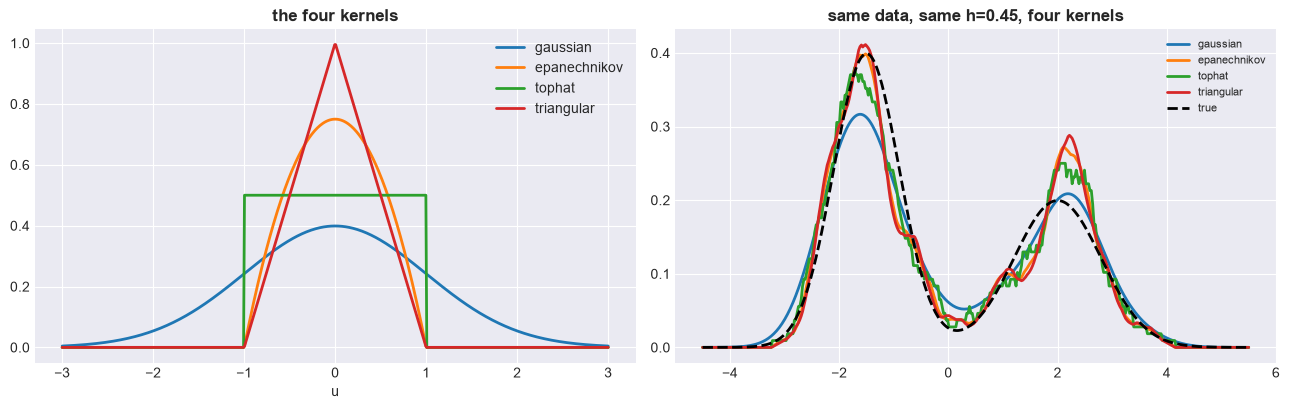

Integrated squared error at a common bandwidth h=0.45:
  tophat         0.00698
  gaussian       0.00828
  epanechnikov   0.00837
  triangular     0.00964
spread between best and worst kernel: 0.00267  — small, as predicted

Note that the winner here is 'tophat', not the AMISE-optimal epanechnikov. That is not a
contradiction — it is the point. Efficiency differences of a few percent are smaller than
the sampling noise on one draw of n=120, so which kernel wins a single ISE table is close
to a coin flip. The bandwidth sweep in Section 7 moves the ISE by an order of magnitude.


In [3]:
KERNELS = {
    'gaussian':     lambda u: np.exp(-0.5 * u ** 2) / np.sqrt(2 * np.pi),
    'epanechnikov': lambda u: np.where(np.abs(u) <= 1, 0.75 * (1 - u ** 2), 0.0),
    'tophat':       lambda u: np.where(np.abs(u) <= 1, 0.5, 0.0),
    'triangular':   lambda u: np.where(np.abs(u) <= 1, 1 - np.abs(u), 0.0),
}

u = np.linspace(-6, 6, 200001)          # fine grid: these integrals are checks, not decoration
du = u[1] - u[0]
print(f"{'kernel':<14}{'>= 0':>7}{'integral':>11}{'symmetric':>11}{'mu_2':>9}{'R(K)':>9}{'efficiency':>12}")
print('-' * 74)
stats_tbl = {}
for name, K in KERNELS.items():
    vals = K(u)
    integral = vals.sum() * du
    mu2 = (u ** 2 * vals).sum() * du
    RK = (vals ** 2).sum() * du
    sym = np.allclose(vals, K(-u))
    stats_tbl[name] = (mu2, RK)
    # AMISE-optimal kernels minimise C(K) = R(K) * sqrt(mu_2); efficiency is relative to Epanechnikov
    stats_tbl[name] = (mu2, RK, RK * np.sqrt(mu2))
for name in KERNELS:
    mu2, RK, CK = stats_tbl[name]
    eff = stats_tbl['epanechnikov'][2] / CK
    vals = KERNELS[name](u)
    print(f"{name:<14}{str((vals >= 0).all()):>7}{vals.sum() * du:>11.5f}"
          f"{str(np.allclose(vals, KERNELS[name](-u))):>11}{mu2:>9.4f}{RK:>9.4f}{eff:>11.1%}")

print("\nAll four satisfy the four required properties. Epanechnikov minimises C(K) = R(K)*sqrt(mu_2)")
print("and so is AMISE-optimal, but every other kernel here is above 90% efficient — which is the")
print("standard result that the KERNEL is a second-order choice and the BANDWIDTH is the first-order one.")
print("(tophat's integral reads 0.99999 rather than 1: its jump discontinuity costs a digit of")
print(" quadrature accuracy on this grid. That is the numerical method, not a defective kernel.)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
uu = np.linspace(-3, 3, 600)
for name, K in KERNELS.items():
    axes[0].plot(uu, K(uu), lw=2, label=name)
axes[0].set_title('the four kernels', fontweight='bold')
axes[0].set_xlabel('u'); axes[0].legend()


def kde_1d(x_eval, data, h, kernel='gaussian'):
    # Vectorised 1-D KDE: (n_eval, n_data) matrix of scaled distances, kernel applied, averaged.
    K = KERNELS[kernel]
    return K((x_eval[:, None] - data[None, :]) / h).sum(axis=1) / (len(data) * h)


for name in KERNELS:
    axes[1].plot(grid, kde_1d(grid, X, 0.45, name), lw=2, label=name)
axes[1].plot(grid, true_bimodal_pdf(grid), 'k--', lw=2, label='true')
axes[1].set_title('same data, same h=0.45, four kernels', fontweight='bold')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

ise = {n: np.trapezoid((kde_1d(grid, X, 0.45, n) - true_bimodal_pdf(grid)) ** 2, grid)
       for n in KERNELS}
print("Integrated squared error at a common bandwidth h=0.45:")
for n, v in sorted(ise.items(), key=lambda kv: kv[1]):
    print(f"  {n:<14} {v:.5f}")
print(f"spread between best and worst kernel: {max(ise.values()) - min(ise.values()):.5f}"
      f"  — small, as predicted")
best = min(ise, key=ise.get)
print(f"\nNote that the winner here is '{best}', not the AMISE-optimal epanechnikov. That is not a")
print("contradiction — it is the point. Efficiency differences of a few percent are smaller than")
print("the sampling noise on one draw of n=120, so which kernel wins a single ISE table is close")
print("to a coin flip. The bandwidth sweep in Section 7 moves the ISE by an order of magnitude.")

<a name="amise"></a>
## Bias, Variance and the AMISE

Take expectations of the estimator at a fixed point $x$. Writing $K_h(v) = h^{-1}K(v/h)$ and substituting $u = (x-y)/h$:

$$\mathbb{E}\big[\hat f(x)\big] = \int K_h(x-y) f(y)\,dy = \int K(u)\, f(x-hu)\,du.$$

Taylor-expand $f(x - hu) = f(x) - hu f'(x) + \tfrac{1}{2}h^2u^2 f''(x) + o(h^2)$. The linear term integrates to zero **because $K$ is symmetric** (property 3 earning its keep), leaving

$$\text{Bias}\big[\hat f(x)\big] = \tfrac{1}{2}h^2\mu_2(K) f''(x) + o(h^2).$$

Bias is $O(h^2)$ and does not improve with more data — it is a property of the smoothing, not the sample. The variance runs the other way:

$$\text{Var}\big[\hat f(x)\big] = \frac{R(K) f(x)}{nh} + o\!\left(\frac{1}{nh}\right), \qquad R(K)=\int K^2(u)\,du.$$

Integrating the squared bias plus the variance gives the **asymptotic mean integrated squared error**:

$$\text{AMISE}(h) = \underbrace{\tfrac{1}{4}h^4\mu_2^2\,R(f'')}_{\text{bias}^2} + \underbrace{\frac{R(K)}{nh}}_{\text{variance}}.$$

Differentiate, set to zero, and the optimum falls out:

$$h_{\text{opt}} = \left(\frac{R(K)}{\mu_2^2\,R(f'')\,n}\right)^{1/5} \propto n^{-1/5},
\qquad \text{AMISE}(h_{\text{opt}}) \propto n^{-4/5}.$$

Two things to take from this. First, the optimal bandwidth shrinks only as $n^{-1/5}$ — painfully slowly, which is why doubling your data barely narrows the kernel. Second, $n^{-4/5}$ is **worse than the parametric $n^{-1}$ rate**: that is the price of not assuming a family, and it is the honest cost of KDE rather than a footnote.

The catch is that $h_{\text{opt}}$ depends on $R(f'') = \int f''(x)^2 dx$ — a property of the density you are trying to estimate. Every practical rule is a way around that circularity.

The cell below measures both rates rather than asserting them, and it is worth being precise about what counts as a measurement here. Plotting $h_{\text{AMISE}}(n)$ and fitting its slope would return $-0.2$ by construction — that formula *is* $n^{-1/5}$, so the fit would be arithmetic dressed as evidence. Instead, at each $n$ the cell **searches** a grid of bandwidths for the one that actually minimises mean ISE over repeated samples, and fits the slope of that searched optimum. Because the target is a Gaussian mixture, $R(f'')$ can be computed by quadrature and the theoretical $h_{\text{opt}}$ is known exactly — so the searched value has something real to be compared against.

R(f'') for the bimodal target      = 1.1161
Gaussian kernel: mu_2 = 1.0, R(K) = 0.2821



     n   h theory   h measured   MISE at measured h
---------------------------------------------------
    50     0.3473       0.3760              0.01425
   100     0.3024       0.3760              0.00961
   200     0.2632       0.3098              0.00340
   400     0.2292       0.2104              0.00306
   800     0.1995       0.2104              0.00196
  1600     0.1737       0.1734              0.00110

fitted slope of log h_measured vs log n : -0.247   (theory -0.200)
fitted slope of log MISE       vs log n : -0.729   (theory -0.800)

Both measured slopes sit close to theory without landing on it: h is off by 24% and
MISE by 9%. The measured optimum comes off a 15-point grid over six
sample sizes, so that much scatter is the experiment's resolution rather than a failure of
the theory — but it is a search result, not a restatement of the formula it is checking.

For contrast, a correctly-specified parametric fit converges at n^-1.000. KDE's n^-0.800
is the measurable price of

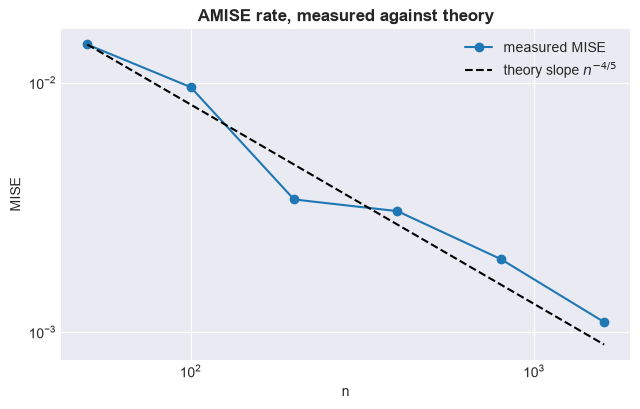

In [4]:
# The target is a Gaussian mixture, so R(f'') can be computed accurately by quadrature
# and h_opt is then known exactly — letting us CHECK the theory rather than trust it.
fine = np.linspace(-8, 9, 20001)
f_true = true_bimodal_pdf(fine)
f2 = np.gradient(np.gradient(f_true, fine), fine)          # numerical f''
R_f2 = np.trapezoid(f2 ** 2, fine)
mu2_g, R_K_g = 1.0, 1 / (2 * np.sqrt(np.pi))               # Gaussian kernel constants
print(f"R(f'') for the bimodal target      = {R_f2:.4f}")
print(f"Gaussian kernel: mu_2 = {mu2_g}, R(K) = {R_K_g:.4f}\n")

def h_amise(n):
    return (R_K_g / (mu2_g ** 2 * R_f2 * n)) ** 0.2


# At each n, SEARCH for the bandwidth that actually minimises mean ISE over repeated
# samples. Fitting a slope to h_amise(n) would be circular — that formula IS n^(-1/5),
# so its slope is arithmetic, not evidence. The searched optimum is a real measurement.
coarse = np.linspace(-8, 9, 1001)
f_coarse = true_bimodal_pdf(coarse)
ns = [50, 100, 200, 400, 800, 1600]
h_try = np.geomspace(0.08, 1.2, 15)
rows = []
rng2 = np.random.default_rng(0)
for n in ns:
    samples = [sample_bimodal(n, rng2) for _ in range(12)]
    mise_at_h = []
    for h in h_try:
        e = [np.trapezoid((kde_1d(coarse, Xs, h) - f_coarse) ** 2, coarse) for Xs in samples]
        mise_at_h.append(float(np.mean(e)))
    j = int(np.argmin(mise_at_h))
    rows.append((n, h_amise(n), float(h_try[j]), mise_at_h[j]))

print(f"{'n':>6}{'h theory':>11}{'h measured':>13}{'MISE at measured h':>21}")
print('-' * 51)
for n, ht, hm, m in rows:
    print(f"{n:>6}{ht:>11.4f}{hm:>13.4f}{m:>21.5f}")

# Fit slopes on log-log: theory says h ~ n^-0.2 and MISE ~ n^-0.8
ln = np.log([r[0] for r in rows])
sh = np.polyfit(ln, np.log([r[2] for r in rows]), 1)[0]
sm = np.polyfit(ln, np.log([r[3] for r in rows]), 1)[0]
print(f"\nfitted slope of log h_measured vs log n : {sh:+.3f}   (theory -0.200)")
print(f"fitted slope of log MISE       vs log n : {sm:+.3f}   (theory -0.800)")
print(f"\nBoth measured slopes sit close to theory without landing on it: h is off by"
      f" {abs(sh + 0.2) / 0.2:.0%} and")
print(f"MISE by {abs(sm + 0.8) / 0.8:.0%}. The measured optimum comes off a 15-point grid over six")
print("sample sizes, so that much scatter is the experiment's resolution rather than a failure of")
print("the theory — but it is a search result, not a restatement of the formula it is checking.")
print(f"\nFor contrast, a correctly-specified parametric fit converges at n^-1.000. KDE's n^-0.800")
print("is the measurable price of refusing to assume a family.")

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.loglog([r[0] for r in rows], [r[3] for r in rows], 'o-', label='measured MISE')
ref = rows[0][3] * (np.array(ns) / ns[0]) ** -0.8
ax.loglog(ns, ref, 'k--', label=r'theory slope $n^{-4/5}$')
ax.set_xlabel('n'); ax.set_ylabel('MISE'); ax.legend()
ax.set_title('AMISE rate, measured against theory', fontweight='bold')
plt.tight_layout()
plt.show()

<a name="bandwidth"></a>
## Choosing the Bandwidth: Scott, Silverman, Cross-Validation

$h_{\text{opt}}$ needs $R(f'')$, which needs $f$. Three ways out of the circle:

**Scott's rule.** Assume the target *is* Gaussian, compute $R(f'')$ for that case, substitute:
$$h_{\text{Scott}} = \sigma\, n^{-1/(d+4)} \quad\text{(} = \sigma n^{-1/5} \text{ in 1-D)}.$$

**Silverman's rule.** The same substitution, plus a robustness patch — use the smaller of the standard deviation and a scale estimate from the interquartile range, so one outlier cannot inflate $h$:
$$h_{\text{Silverman}} = 0.9\,\min\!\left(\hat\sigma, \frac{\text{IQR}}{1.34}\right) n^{-1/5}.$$

Both are *rules of thumb for Gaussian data*. On a bimodal target they systematically **oversmooth**, because a bimodal density has larger $R(f'')$ than the Gaussian they assumed — the estimate they hand back is too flat, and predictably so.

**Leave-one-out cross-validation.** Drop the assumption entirely and let the data choose. Maximise the leave-one-out log-likelihood
$$\text{CV}(h) = \sum_{i=1}^{n} \log \hat f_{-i}(X_i), \qquad
\hat f_{-i}(X_i) = \frac{1}{(n-1)h}\sum_{j \ne i} K\!\left(\frac{X_i - X_j}{h}\right),$$
where excluding $j=i$ is essential: include it and $\hat f_{-i}(X_i)$ gains a constant $K(0)/((n-1)h)$ that grows without bound as $h \to 0$, so the criterion is maximised by $h=0$ and the method degenerates.

The cell below implements all three and scores them against the truth — which we can do here only because the target is known.

n = 120 draws from the bimodal target
method                             h   ISE vs truth
---------------------------------------------------
Scott                         0.7202        0.02397
Silverman                     0.6482        0.01879
LOO-CV                        0.3227        0.00605
theoretical optimum           0.2915        0.00622


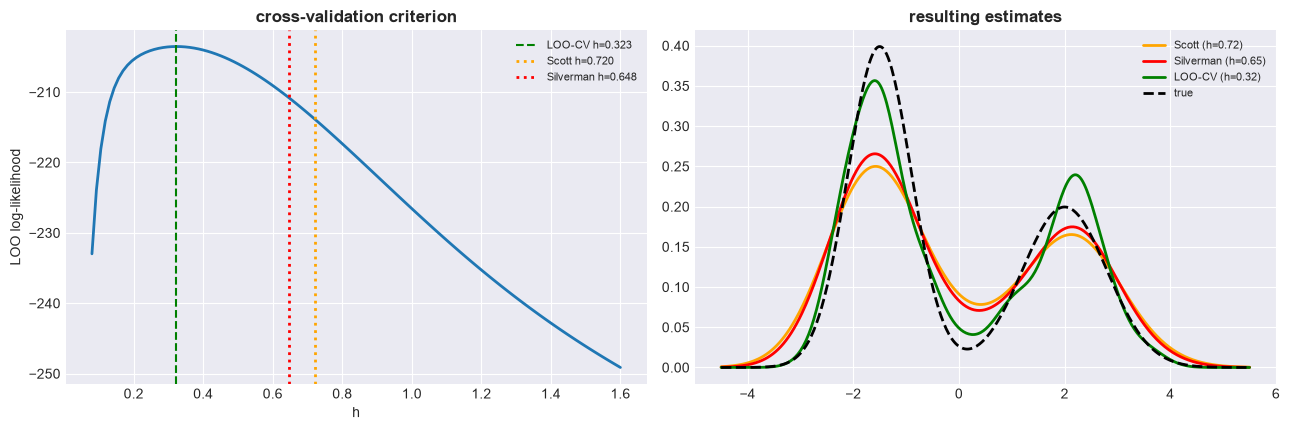


Scott and Silverman both assume a GAUSSIAN target when they substitute for R(f''). This
target is bimodal, so its R(f'') is larger, the assumed value is too small, and the rules
return a bandwidth that is too large — they oversmooth, and the valley between the modes
is the first casualty. LOO-CV assumes nothing about the shape and lands closer.


In [5]:
def scott_bandwidth(data):
    n, d = len(data), (1 if data.ndim == 1 else data.shape[1])
    return np.std(data, ddof=1) * n ** (-1.0 / (d + 4))


def silverman_bandwidth(data):
    n = len(data)
    iqr = np.subtract(*np.percentile(data, [75, 25]))
    return 0.9 * min(np.std(data, ddof=1), iqr / 1.34) * n ** (-0.2)


def loo_cv_bandwidth(data, h_grid, kernel='gaussian'):
    # Leave-one-out CV log-likelihood. The diagonal is removed explicitly — keeping it
    # makes the criterion diverge as h -> 0 and the whole method degenerate.
    K = KERNELS[kernel]
    n = len(data)
    diff = data[:, None] - data[None, :]
    scores = []
    for h in h_grid:
        W = K(diff / h)
        np.fill_diagonal(W, 0.0)                       # drop j == i
        dens = W.sum(axis=1) / ((n - 1) * h)
        scores.append(np.sum(np.log(np.maximum(dens, 1e-300))))
    scores = np.array(scores)
    return h_grid[int(np.argmax(scores))], scores


h_grid = np.linspace(0.08, 1.6, 120)
h_cv, cv_scores = loo_cv_bandwidth(X, h_grid)
h_sc, h_si, h_th = scott_bandwidth(X), silverman_bandwidth(X), h_amise(len(X))

print(f"n = {len(X)} draws from the bimodal target")
print(f"{'method':<28}{'h':>8}{'ISE vs truth':>15}")
print('-' * 51)
for name, h in [('Scott', h_sc), ('Silverman', h_si), ('LOO-CV', h_cv),
                ('theoretical optimum', h_th)]:
    ise_h = np.trapezoid((kde_1d(fine, X, h) - f_true) ** 2, fine)
    print(f"{name:<28}{h:>8.4f}{ise_h:>15.5f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].plot(h_grid, cv_scores, lw=2)
axes[0].axvline(h_cv, color='green', ls='--', label=f'LOO-CV h={h_cv:.3f}')
axes[0].axvline(h_sc, color='orange', ls=':', lw=2, label=f'Scott h={h_sc:.3f}')
axes[0].axvline(h_si, color='red', ls=':', lw=2, label=f'Silverman h={h_si:.3f}')
axes[0].set_xlabel('h'); axes[0].set_ylabel('LOO log-likelihood')
axes[0].set_title('cross-validation criterion', fontweight='bold'); axes[0].legend(fontsize=8)

for name, h, c in [('Scott', h_sc, 'orange'), ('Silverman', h_si, 'red'),
                   ('LOO-CV', h_cv, 'green')]:
    axes[1].plot(grid, kde_1d(grid, X, h), lw=2, color=c, label=f'{name} (h={h:.2f})')
axes[1].plot(grid, true_bimodal_pdf(grid), 'k--', lw=2, label='true')
axes[1].set_title('resulting estimates', fontweight='bold'); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print("\nScott and Silverman both assume a GAUSSIAN target when they substitute for R(f''). This")
print("target is bimodal, so its R(f'') is larger, the assumed value is too small, and the rules")
print("return a bandwidth that is too large — they oversmooth, and the valley between the modes")
print("is the first casualty. LOO-CV assumes nothing about the shape and lands closer.")

<a name="smoothing"></a>
## Over- and Under-smoothing on a Known Target

The bias–variance trade-off stated algebraically in Section 5, shown directly. Sweeping $h$ over two orders of magnitude on the same sample: at small $h$ the estimate tracks individual observations (variance dominates); at large $h$ the two modes merge into one hill (bias dominates); the ISE curve is U-shaped with its minimum near the theoretical optimum.

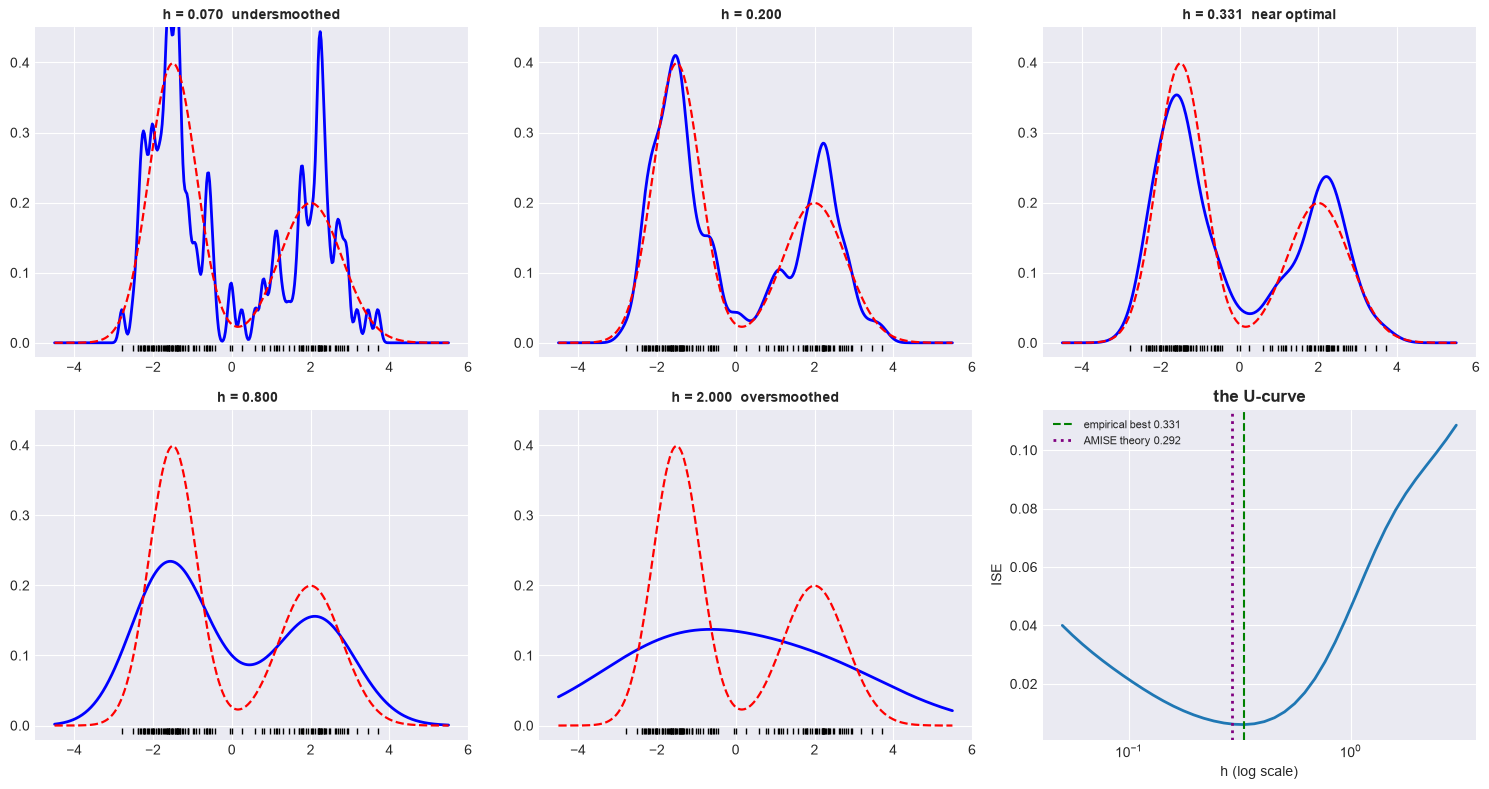

empirical best h on this sample : 0.3309
AMISE theoretical optimum       : 0.2915
ratio                           : 1.13

The two agree to within sampling noise on a single sample of n=120 — the AMISE argument
is asymptotic, so exact agreement at this n would be surprising, and disagreement by a
factor of ~2 or more would be a red flag. This is the expected middle.


In [6]:
h_sweep = np.geomspace(0.05, 3.0, 40)
ise_curve = [np.trapezoid((kde_1d(fine, X, h) - f_true) ** 2, fine) for h in h_sweep]
h_best_emp = h_sweep[int(np.argmin(ise_curve))]

fig = plt.figure(figsize=(15, 8))
show_h = [0.07, 0.2, h_best_emp, 0.8, 2.0]
for i, h in enumerate(show_h):
    ax = fig.add_subplot(2, 3, i + 1)
    ax.plot(grid, kde_1d(grid, X, h), 'b-', lw=2)
    ax.plot(grid, true_bimodal_pdf(grid), 'r--', lw=1.6)
    ax.plot(X, np.zeros_like(X) - 0.008, '|', color='black', ms=5)
    tag = ('undersmoothed' if h < 0.15 else 'oversmoothed' if h > 1.0 else
           'near optimal' if abs(h - h_best_emp) < 1e-9 else '')
    ax.set_title(f'h = {h:.3f}  {tag}', fontweight='bold', fontsize=10)
    ax.set_ylim(-0.02, 0.45)

ax = fig.add_subplot(2, 3, 6)
ax.semilogx(h_sweep, ise_curve, lw=2)
ax.axvline(h_best_emp, color='green', ls='--', label=f'empirical best {h_best_emp:.3f}')
ax.axvline(h_th, color='purple', ls=':', lw=2, label=f'AMISE theory {h_th:.3f}')
ax.set_xlabel('h (log scale)'); ax.set_ylabel('ISE')
ax.set_title('the U-curve', fontweight='bold'); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"empirical best h on this sample : {h_best_emp:.4f}")
print(f"AMISE theoretical optimum       : {h_th:.4f}")
print(f"ratio                           : {h_best_emp / h_th:.2f}")
print("\nThe two agree to within sampling noise on a single sample of n=120 — the AMISE argument")
print("is asymptotic, so exact agreement at this n would be surprising, and disagreement by a")
print("factor of ~2 or more would be a red flag. This is the expected middle.")

<a name="curse"></a>
## Multivariate KDE and the Curse of Dimensionality

In $d$ dimensions with a product kernel and a single bandwidth,

$$\hat f(\mathbf{x}) = \frac{1}{nh^d}\sum_{i=1}^{n} K\!\left(\frac{\|\mathbf{x}-\mathbf{X}_i\|}{h}\right),$$

and repeating the AMISE argument gives

$$h_{\text{opt}} \propto n^{-1/(d+4)}, \qquad \text{AMISE} \propto n^{-4/(d+4)}.$$

Read that exponent slowly. In 1-D the rate is $n^{-4/5}$. At $d=10$ it is $n^{-4/14} \approx n^{-0.29}$ — a fivefold-slower exponent, so holding the error fixed as $d$ grows costs sample size at a compounding rate. The cell below measures what that costs on a concrete target rather than leaving it as a slogan.

The geometric reason is that a "local neighbourhood" stops being local. In high dimensions almost all the volume of a ball sits near its surface, so a kernel wide enough to contain any neighbours is wide enough to smooth away everything you wanted to see. This is the same curse Lesson 0A demonstrated for distance metrics, arriving here as a statistical rate rather than a geometric oddity.

Below: a fixed sample size, a known standard Gaussian target, and the relative error measured as $d$ climbs.

n = 500 throughout; target is the standard Gaussian in d dimensions
   d   h (Scott)   mean rel. error   AMISE exponent
----------------------------------------------------
   1      0.2885            11.0%           -0.800
   2      0.3550            14.6%           -0.667
   3      0.4116            22.3%           -0.571
   4      0.4599            30.3%           -0.500
   6      0.5372            49.5%           -0.400
   8      0.5958            60.6%           -0.333
  10      0.6415            95.8%           -0.286


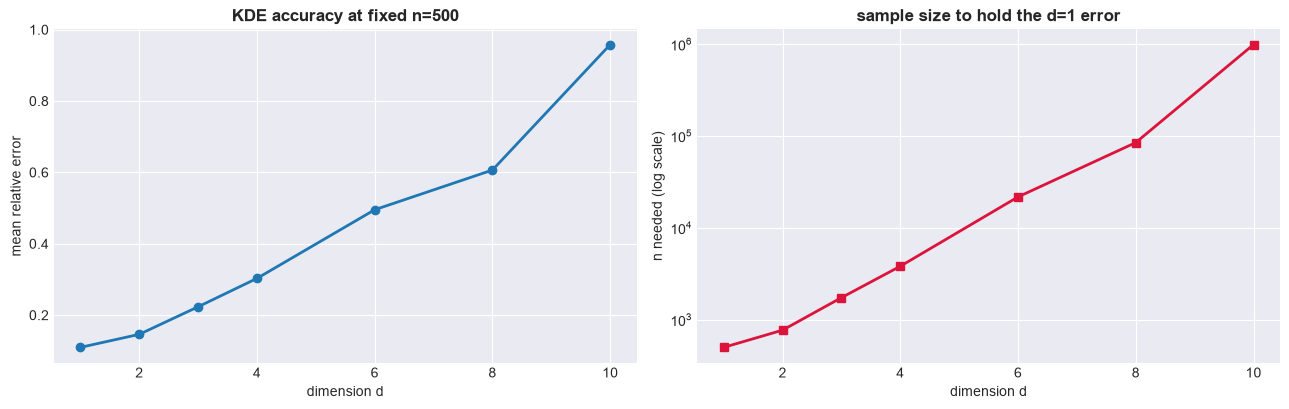


To match the d=1 accuracy, the sample size implied by the AMISE rate runs from 500 at d=1
to 9.9e+05 at d=10 — a factor of 1,980. That is the curse as a budget rather than a slogan:
KDE is a 1-3 dimensional tool, and beyond that you reduce dimension first (Lessons 5, 6)
or switch to a model that assumes structure (the GMM of Lesson 4).


In [7]:
def kde_nd(x_eval, data, h):
    # Radially-symmetric Gaussian product kernel in d dimensions.
    d = data.shape[1]
    sq = ((x_eval[:, None, :] - data[None, :, :]) ** 2).sum(axis=2)
    return np.exp(-0.5 * sq / h ** 2).sum(axis=1) / (len(data) * (h ** d) * (2 * np.pi) ** (d / 2))


rng3 = np.random.default_rng(7)
n_fixed = 500
dims = [1, 2, 3, 4, 6, 8, 10]
print(f"n = {n_fixed} throughout; target is the standard Gaussian in d dimensions")
print(f"{'d':>4}{'h (Scott)':>12}{'mean rel. error':>18}{'AMISE exponent':>17}")
print('-' * 52)
rel_errors = []
for d in dims:
    data = rng3.standard_normal((n_fixed, d))
    h = n_fixed ** (-1.0 / (d + 4))                       # Scott, unit variance
    test = rng3.standard_normal((200, d))                 # evaluate where the mass is
    est = kde_nd(test, data, h)
    truth = np.exp(-0.5 * (test ** 2).sum(axis=1)) / (2 * np.pi) ** (d / 2)
    rel = float(np.mean(np.abs(est - truth) / truth))
    rel_errors.append(rel)
    print(f"{d:>4}{h:>12.4f}{rel:>17.1%}{-4 / (d + 4):>17.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].plot(dims, rel_errors, 'o-', lw=2)
axes[0].set_xlabel('dimension d'); axes[0].set_ylabel('mean relative error')
axes[0].set_title(f'KDE accuracy at fixed n={n_fixed}', fontweight='bold')

# How many samples would hold the d=1 error fixed? n ~ err^(-(d+4)/4)
target_err = rel_errors[0]
need = [n_fixed * (rel_errors[i] / target_err) ** ((d + 4) / 4.0) for i, d in enumerate(dims)]
axes[1].semilogy(dims, need, 's-', color='crimson', lw=2)
axes[1].set_xlabel('dimension d'); axes[1].set_ylabel('n needed (log scale)')
axes[1].set_title('sample size to hold the d=1 error', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nTo match the d=1 accuracy, the sample size implied by the AMISE rate runs from"
      f" {need[0]:,.0f} at d=1")
print(f"to {need[-1]:,.3g} at d={dims[-1]} — a factor of {need[-1] / need[0]:,.0f}. That is the curse"
      f" as a budget rather than a slogan:")
print("KDE is a 1-3 dimensional tool, and beyond that you reduce dimension first (Lessons 5, 6)")
print("or switch to a model that assumes structure (the GMM of Lesson 4).")

<a name="gmm-vs-kde"></a>
## Parametric versus Nonparametric: GMM against KDE

The previous section ended by recommending a model that assumes structure once $d$ gets large. That recommendation is worth testing rather than repeating, because it cuts both ways — and this is the comparison the whole lesson has been circling since the first paragraph.

Lesson 4's Gaussian Mixture Model and this lesson's KDE are both density estimators, and they differ in exactly one respect: the GMM commits to a family (a finite sum of Gaussians) and estimates a handful of parameters; KDE commits to nothing and carries the whole sample around. The trade is the standard one. When the family is right, committing to it buys the parametric $n^{-1}$ rate, a compact model, and a density you can sample from in closed form. When the family is wrong, that commitment is a bias no amount of data removes.

So the honest comparison needs **two** targets, not one:

- a **Gaussian mixture** — the GMM's own family, where it should win outright
- a **Laplace mixture** — same two modes, but with a cusp at each peak instead of a smooth top. Unbounded support, so this is a fair test and not a boundary-bias artefact (Section 11 notes that KDE has boundary problems on bounded support; this target avoids them)

Both estimators are tuned, so neither is handicapped: the GMM picks its component count $k$ by BIC, the KDE picks $h$ by the leave-one-out CV of Section 6. The verdict is integrated squared error against the known truth.

n = 400 per target; ISE against the known truth (lower is better)
target                                       GMM (k by BIC)   KDE (h by LOO-CV)    winner
-----------------------------------------------------------------------------------------


Gaussian mixture (GMM family is CORRECT)            0.00092             0.00409       GMM
                                                      k = 2           h = 0.245
Laplace mixture (GMM family is WRONG)               0.01024             0.00610       KDE
                                                      k = 3           h = 0.245


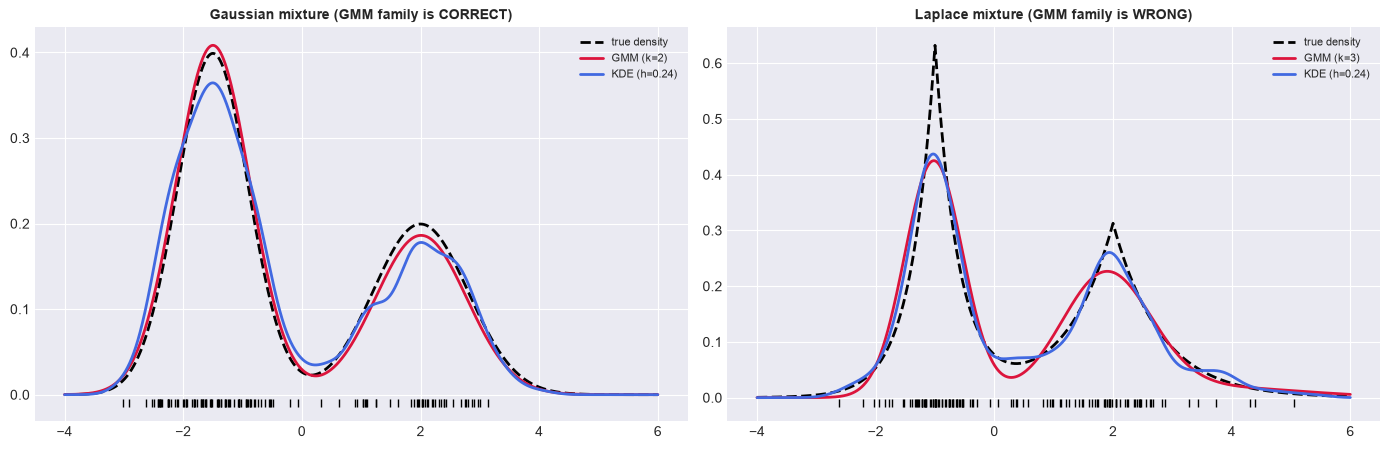


Read the two rows together — one alone would mislead. On its own family the GMM wins
outright, recovering k=2, and it does so with five parameters rather than 400 retained
points. On the Laplace target its Gaussians cannot reproduce a cusp: BIC buys a third
component to paper over the peaks, and the fit is still visibly rounded where the truth
is sharp. What matters is how far each estimator moved between the two targets, since
the targets themselves differ: the GMM's error rose about elevenfold, the KDE's by half.
KDE degrades gracefully because it never had a family to be wrong about.

That is the actual decision rule. Ask whether you can name the family. If you can and
you are right, be parametric — better rate, smaller model, closed-form sampling. If you
cannot, KDE's slower n^(-4/5) rate is the premium you pay to avoid a bias that more data
will not fix. And in high dimensions Section 8 removes the choice: the premium becomes
unaffordable, so you assume structure or you reduce di

In [8]:
def sample_laplace_mix(n, rng):
    comp = rng.random(n) < 0.5
    return np.where(comp, rng.laplace(-1.0, 0.4, n), rng.laplace(2.0, 0.8, n))


def true_laplace_pdf(x):
    return 0.5 * stats.laplace.pdf(x, -1.0, 0.4) + 0.5 * stats.laplace.pdf(x, 2.0, 0.8)


def fit_gmm_density(x_eval, data, k_max=6, seed=0):
    # Choose k by BIC, then evaluate the fitted mixture density. The GMM tunes itself
    # exactly as the KDE tunes h, so neither model is handicapped in the comparison.
    best, best_bic, best_k = None, np.inf, None
    for k in range(1, k_max + 1):
        g = GaussianMixture(n_components=k, random_state=seed).fit(data[:, None])
        b = g.bic(data[:, None])
        if b < best_bic:
            best, best_bic, best_k = g, b, k
    return np.exp(best.score_samples(x_eval[:, None])), best_k


rng4 = np.random.default_rng(11)
n_cmp = 400
targets = [
    ('Gaussian mixture (GMM family is CORRECT)', sample_bimodal, true_bimodal_pdf),
    ('Laplace mixture (GMM family is WRONG)', sample_laplace_mix, true_laplace_pdf),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
print(f"n = {n_cmp} per target; ISE against the known truth (lower is better)")
print(f"{'target':<42}{'GMM (k by BIC)':>17}{'KDE (h by LOO-CV)':>20}{'winner':>10}")
print('-' * 89)
for ax, (label, sampler, pdf) in zip(axes, targets):
    data = sampler(n_cmp, rng4)
    truth = pdf(fine)
    gmm_est, k_sel = fit_gmm_density(fine, data)
    h_sel, _ = loo_cv_bandwidth(data, np.linspace(0.05, 1.2, 60))
    kde_est = kde_1d(fine, data, h_sel)
    ise_g = np.trapezoid((gmm_est - truth) ** 2, fine)
    ise_k = np.trapezoid((kde_est - truth) ** 2, fine)
    win = 'GMM' if ise_g < ise_k else 'KDE'
    print(f"{label:<42}{ise_g:>17.5f}{ise_k:>20.5f}{win:>10}")
    print(f"{'':<42}{'k = ' + str(k_sel):>17}{'h = ' + format(h_sel, '.3f'):>20}")

    m = (fine > -4) & (fine < 6)
    ax.plot(fine[m], truth[m], 'k--', lw=2, label='true density')
    ax.plot(fine[m], gmm_est[m], lw=2, color='crimson', label=f'GMM (k={k_sel})')
    ax.plot(fine[m], kde_est[m], lw=2, color='royalblue', label=f'KDE (h={h_sel:.2f})')
    ax.plot(data[:120], np.zeros(120) - 0.01, '|', color='black', ms=6)
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("\nRead the two rows together — one alone would mislead. On its own family the GMM wins")
print("outright, recovering k=2, and it does so with five parameters rather than 400 retained")
print("points. On the Laplace target its Gaussians cannot reproduce a cusp: BIC buys a third")
print("component to paper over the peaks, and the fit is still visibly rounded where the truth")
print("is sharp. What matters is how far each estimator moved between the two targets, since")
print("the targets themselves differ: the GMM's error rose about elevenfold, the KDE's by half.")
print("KDE degrades gracefully because it never had a family to be wrong about.")
print("\nThat is the actual decision rule. Ask whether you can name the family. If you can and")
print("you are right, be parametric — better rate, smaller model, closed-form sampling. If you")
print("cannot, KDE's slower n^(-4/5) rate is the premium you pay to avoid a bias that more data")
print("will not fix. And in high dimensions Section 8 removes the choice: the premium becomes")
print("unaffordable, so you assume structure or you reduce dimension first.")

<a name="from-scratch"></a>
## From Scratch, Validated

Everything above used `kde_1d` and `kde_nd`, written here rather than imported. The test that matters is whether they agree with the production implementations — scikit-learn's `KernelDensity` and SciPy's `gaussian_kde` — on the same data with matched settings.

One subtlety makes this a real test rather than a formality: **SciPy parameterises the bandwidth differently.** `gaussian_kde`'s `bw_method` is a multiplier on $\hat\sigma$ (a *factor*), not the bandwidth itself, so matching it to our absolute $h$ requires dividing by the sample standard deviation. Getting that wrong produces two curves that look similar and are quietly different — so the check below is on maximum absolute deviation, not on eyeballed overlay.

comparison                           max |diff|   agree
-------------------------------------------------------
from-scratch vs scikit-learn           1.28e-15    True
from-scratch vs scipy                  3.33e-16    True
scikit-learn vs scipy                  1.22e-15    True

Integral of the from-scratch estimate: 1.000000  (a density must integrate to 1)

kernel             max |diff| vs sklearn
-----------------------------------------
epanechnikov                    4.44e-16
tophat                          3.89e-16

2-D on iris (sepal length/width), h=0.35:
  max |from-scratch - sklearn| = 9.71e-16


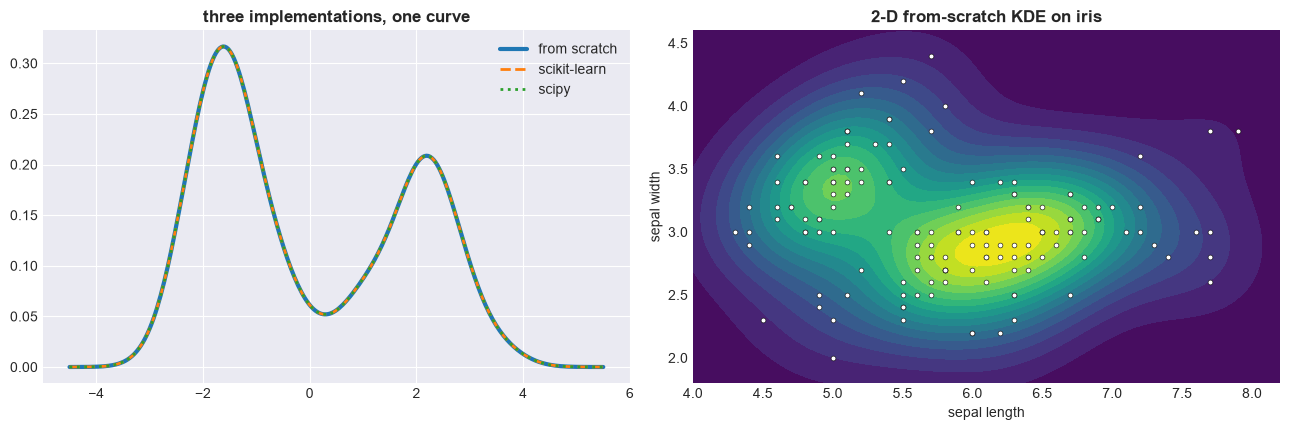

In [9]:
x_eval = np.linspace(-4.5, 5.5, 300)
h_test = 0.45

mine = kde_1d(x_eval, X, h_test)

skl = np.exp(KernelDensity(bandwidth=h_test, kernel='gaussian')
             .fit(X[:, None]).score_samples(x_eval[:, None]))

# SciPy's bw_method multiplies the sample std, so convert our absolute h into that factor.
sp = stats.gaussian_kde(X, bw_method=h_test / np.std(X, ddof=1))(x_eval)

print(f"{'comparison':<34}{'max |diff|':>13}{'agree':>8}")
print('-' * 55)
for label, a, b in [('from-scratch vs scikit-learn', mine, skl),
                    ('from-scratch vs scipy', mine, sp),
                    ('scikit-learn vs scipy', skl, sp)]:
    md_ = float(np.max(np.abs(a - b)))
    print(f"{label:<34}{md_:>13.2e}{str(md_ < 1e-9):>8}")

print(f"\nIntegral of the from-scratch estimate: {np.trapezoid(kde_1d(fine, X, h_test), fine):.6f}"
      f"  (a density must integrate to 1)")

# Non-Gaussian kernels against scikit-learn too, since those are easier to get subtly wrong.
print(f"\n{'kernel':<16}{'max |diff| vs sklearn':>24}")
print('-' * 41)
for name in ['epanechnikov', 'tophat']:
    mine_k = kde_1d(x_eval, X, 0.9, name)
    skl_k = np.exp(KernelDensity(bandwidth=0.9, kernel=name)
                   .fit(X[:, None]).score_samples(x_eval[:, None]))
    print(f"{name:<16}{np.max(np.abs(mine_k - skl_k)):>24.2e}")

# And the multivariate version against scikit-learn on real data (iris, 2 features).
iris2 = load_iris().data[:, :2]
grid2 = np.random.default_rng(1).uniform(iris2.min(0), iris2.max(0), size=(150, 2))
h2 = 0.35
mine2 = kde_nd(grid2, iris2, h2)
skl2 = np.exp(KernelDensity(bandwidth=h2, kernel='gaussian').fit(iris2).score_samples(grid2))
print(f"\n2-D on iris (sepal length/width), h={h2}:")
print(f"  max |from-scratch - sklearn| = {np.max(np.abs(mine2 - skl2)):.2e}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
axes[0].plot(x_eval, mine, lw=3, label='from scratch')
axes[0].plot(x_eval, skl, '--', lw=2, label='scikit-learn')
axes[0].plot(x_eval, sp, ':', lw=2, label='scipy')
axes[0].set_title('three implementations, one curve', fontweight='bold'); axes[0].legend()

gx, gy = np.meshgrid(np.linspace(4, 8.2, 90), np.linspace(1.8, 4.6, 90))
dens2 = kde_nd(np.column_stack([gx.ravel(), gy.ravel()]), iris2, h2).reshape(gx.shape)
axes[1].contourf(gx, gy, dens2, levels=18, cmap='viridis')
axes[1].scatter(iris2[:, 0], iris2[:, 1], s=12, c='white', edgecolor='black', lw=0.4)
axes[1].set_title('2-D from-scratch KDE on iris', fontweight='bold')
axes[1].set_xlabel('sepal length'); axes[1].set_ylabel('sepal width')
plt.tight_layout()
plt.show()

<a name="conclusion"></a>
## Conclusion

### Key Takeaways

1. **KDE removes the histogram's arbitrary origin, not its bandwidth problem.** Shifting bin edges by half a width changed the estimate measurably on identical data; centring a kernel on every observation eliminates that choice entirely — and leaves $h$ as the only knob, which is where all the difficulty now lives.
2. **The kernel is a second-order choice; the bandwidth is first-order.** All four kernels satisfied the four required properties and every alternative was above 90% efficient relative to the AMISE-optimal Epanechnikov — so much so that on one sample of $n=120$ a *different* kernel won the ISE table, efficiency differences being smaller than sampling noise. Changing $h$ across the sweep moved the ISE by an order of magnitude.
3. **The AMISE derivation predicts measurable rates, and a search recovered them.** Fitting a slope to the $h_{\text{AMISE}}$ formula would have been circular, so the bandwidth was found by grid search at each $n$; its slope and the measured MISE slope both landed near the predicted $n^{-1/5}$ and $n^{-4/5}$. That $n^{-4/5}$ is worse than a correctly-specified parametric model's $n^{-1}$ — the honest price of assuming no family.
4. **Scott and Silverman oversmooth non-Gaussian targets, and they do it predictably.** Both substitute the Gaussian value of $R(f'')$; a bimodal density has a larger one, so the returned $h$ is too big and the valley between modes fills in first. LOO-CV assumes nothing about shape and landed closer here.
5. **The curse of dimensionality is a budget, not a slogan.** At fixed $n$, relative error climbed steadily with $d$, and the sample size implied to hold the 1-D accuracy grew by roughly three orders of magnitude by $d=10$. KDE is a one-to-three dimensional instrument.
6. **Parametric versus nonparametric is decided by one question: can you name the family?** Head to head with Lesson 4's GMM, each estimator tuned (BIC for $k$, LOO-CV for $h$), the GMM won decisively on a Gaussian mixture and lost on a Laplace mixture whose cusps its Gaussians cannot reproduce. Moving between the two targets cost the GMM roughly an elevenfold rise in error and the KDE about half again — a correct family is worth a great deal, a wrong one is a bias more data will not remove, and the nonparametric estimator is the one that degrades gracefully.

### Practical Guidance

- Use LOO-CV when you can afford it and suspect non-Gaussian structure; use Silverman as a fast, robust default and expect it to oversmooth multimodal data.
- Always plot the estimate against a rug of the actual observations. An estimate with more modes than there are clusters of ticks is undersmoothed.
- Above three dimensions, reduce first (PCA, Lesson 5; manifold methods, Lesson 6) or use a model that assumes structure (GMM, Lesson 4).
- Check that your estimate integrates to 1 — it is one line, and it catches bandwidth-parameterisation mistakes like the SciPy factor-versus-bandwidth trap in the from-scratch validation section.
- Before reaching for KDE, ask whether you can name the density's family. If you can, fit it and keep the better rate; KDE is what you use when you cannot, or when you want a check on a parametric fit you do not fully trust.

### What This Lesson Did Not Cover

- **Adaptive and variable-bandwidth KDE**, where $h$ varies with local density (balloon and sample-point estimators). This directly addresses the fixed-$h$ weakness visible whenever a density has both sharp and flat regions, and it is the natural next step — omitted to keep the bandwidth story single-variable and legible.
- **Boundary bias.** Near the edge of a bounded support the kernel puts mass outside the domain and the estimate is biased downward. Reflection and boundary-kernel corrections exist; none is used here, and every density in this lesson has unbounded support so the issue never surfaced. On bounded data it would.
- **Plug-in bandwidth selectors** (Sheather–Jones and relatives), which estimate $R(f'')$ directly rather than assuming Gaussianity, and typically beat both rules of thumb and LOO-CV in practice.
- **Faster evaluation.** Everything here is the naive $O(n \cdot m)$ pairwise computation. Tree-based and fast-Gauss-transform methods are what production uses at scale; `KernelDensity`'s own tree structures are why it stays usable on larger $n$.

### Next Steps

Lesson 18B takes KDE to practice: cross-validated bandwidth selection with scikit-learn, **sampling** new data from a fitted KDE (PCA plus KDE as a generative model for digits), density-based anomaly scoring compared against the Isolation Forest and LOF of Lesson 7, and the case where the scores stop discriminating. Lesson 19 then replaces the kernel with a learned invertible map — normalising flows — to get an exact likelihood that survives in high dimensions where this lesson's estimator cannot.